In [9]:
import numpy as np
import healpy as hp
import pymaster as nmt
import matplotlib.pyplot as plt

In [19]:
# Load residuals

nside = 64
lmax = 2*nside-1
lbin = 35
Nlbin = 10

if lbin is None:
    b = nmt.NmtBin.from_lmax_linear(lmax=lmax, nlb=Nlbin, is_Dell=True) # Binning scheme for the cross-spectra
else:
    ell_ini = np.concatenate((np.arange(2, lbin), np.arange(lbin, 3*nside, Nlbin)))
    ell_end = np.concatenate((np.arange(2, lbin)+1, np.arange(lbin, 3*nside, Nlbin)+Nlbin))
    ell_end = ell_end[ell_end <= 3*nside]
    ell_ini = ell_ini[:len(ell_end)]
    b = nmt.NmtBin.from_edges(ell_ini, ell_end, is_Dell=True)
    b.lmax = 3*nside-1

leff = b.get_effective_ells()
leff = leff[leff + (Nlbin+1)/2 <= lmax]

ell = np.arange(2, 128)
Cl_lens = hp.read_cl('../power_spectra/Cls_LiteBIRD_e2e_r0.fits')[2, 2:lmax+1]
Cl_tens = hp.read_cl('../power_spectra/Cls_Planck2018_tensor_r1.fits')[2, 2:lmax+1]

sysFGRs_P_on_QU = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_402_10deg_baseline_Nmt-fg_o1bts/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_B_on_QU = np.load('../../BmodeLike/inputs/moments_baseline_0.5_B_402_10deg_baseline_Nmt-fg_o1bts/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_P_B_on_QU = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_B_402_10deg_baseline_Nmt-fg_o1bts/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi

sysFGRs_P_on_B = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_402_10deg_baseline_Nmt-fg_o1bts_B/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_B_on_B = np.load('../../BmodeLike/inputs/moments_baseline_0.5_B_402_10deg_baseline_Nmt-fg_o1bts_B/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_P_B_on_B = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_B_402_10deg_baseline_Nmt-fg_o1bts_B/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi

sysFGRs_P_on_QBUB = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_402_10deg_baseline_Nmt-fg_o1bts_QBUB/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_B_on_QBUB = np.load('../../BmodeLike/inputs/moments_baseline_0.5_B_402_10deg_baseline_Nmt-fg_o1bts_QBUB/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_P_B_on_QBUB = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_B_402_10deg_baseline_Nmt-fg_o1bts_QBUB/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi

statFGRs_P_on_QU = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_402_10deg_baseline_Nmt-fg_o1bts/namaster_statFGRs.npy') / leff / (leff+1) * 2*np.pi
statFGRs_B_on_QU = np.load('../../BmodeLike/inputs/moments_baseline_0.5_B_402_10deg_baseline_Nmt-fg_o1bts/namaster_statFGRs.npy') / leff / (leff+1) * 2*np.pi
statFGRs_P_B_on_QU = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_B_402_10deg_baseline_Nmt-fg_o1bts/namaster_statFGRs.npy') / leff / (leff+1) * 2*np.pi

statFGRs_P_on_B = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_402_10deg_baseline_Nmt-fg_o1bts_B/namaster_statFGRs.npy') / leff / (leff+1) * 2*np.pi
statFGRs_B_on_B = np.load('../../BmodeLike/inputs/moments_baseline_0.5_B_402_10deg_baseline_Nmt-fg_o1bts_B/namaster_statFGRs.npy') / leff / (leff+1) * 2*np.pi
statFGRs_P_B_on_B = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_B_402_10deg_baseline_Nmt-fg_o1bts_B/namaster_statFGRs.npy') / leff / (leff+1) * 2*np.pi

statFGRs_P_on_QBUB = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_402_10deg_baseline_Nmt-fg_o1bts_QBUB/namaster_statFGRs.npy') / leff / (leff+1) * 2*np.pi
statFGRs_B_on_QBUB = np.load('../../BmodeLike/inputs/moments_baseline_0.5_B_402_10deg_baseline_Nmt-fg_o1bts_QBUB/namaster_statFGRs.npy') / leff / (leff+1) * 2*np.pi
statFGRs_P_B_on_QBUB = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_B_402_10deg_baseline_Nmt-fg_o1bts_QBUB/namaster_statFGRs.npy') / leff / (leff+1) * 2*np.pi

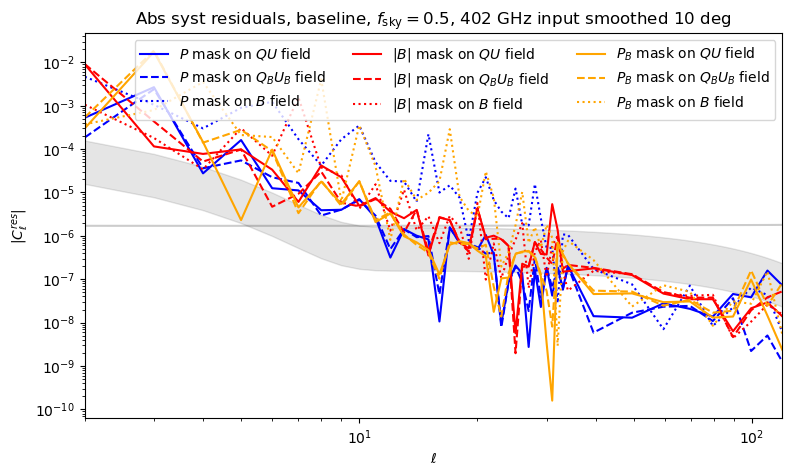

In [30]:
plt.figure(figsize=(9, 5))

plt.plot(ell, Cl_lens, color='black', alpha=0.2)
plt.fill_between(ell, 1e-3*Cl_tens, 1e-2*Cl_tens, color='black', alpha=0.1)

plt.plot(leff, np.abs(sysFGRs_P_on_QU), label=r'$P$ mask on $QU$ field', color='blue')
plt.plot(leff, np.abs(sysFGRs_P_on_QBUB), ls='dashed', label=r'$P$ mask on $Q_B U_B$ field', color='blue')
plt.plot(leff, np.abs(sysFGRs_P_on_B), ls='dotted', label=r'$P$ mask on $B$ field', color='blue')

plt.plot(leff, np.abs(sysFGRs_B_on_QU), label=r'$|B|$ mask on $QU$ field', color='red')
plt.plot(leff, np.abs(sysFGRs_B_on_QBUB), ls='dashed', label=r'$|B|$ mask on $Q_B U_B$ field', color='red')
plt.plot(leff, np.abs(sysFGRs_B_on_B), ls='dotted', label=r'$|B|$ mask on $B$ field', color='red')

plt.plot(leff, np.abs(sysFGRs_P_B_on_QU), label=r'$P_B$ mask on $QU$ field', color='orange')
plt.plot(leff, np.abs(sysFGRs_P_B_on_QBUB), ls='dashed', label=r'$P_B$ mask on $Q_B U_B$ field', color='orange')
plt.plot(leff, np.abs(sysFGRs_P_B_on_B), ls='dotted', label=r'$P_B$ mask on $B$ field', color='orange')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\vert C_\ell^{res} \vert$')
plt.xscale('log')
plt.yscale('log')
plt.xlim(min(leff), max(leff))
plt.legend(ncol=3, loc='upper right')
plt.title(r'Abs syst residuals, baseline, $f_{\rm sky}=0.5$, 402 GHz input smoothed 10 deg')

plt.show()

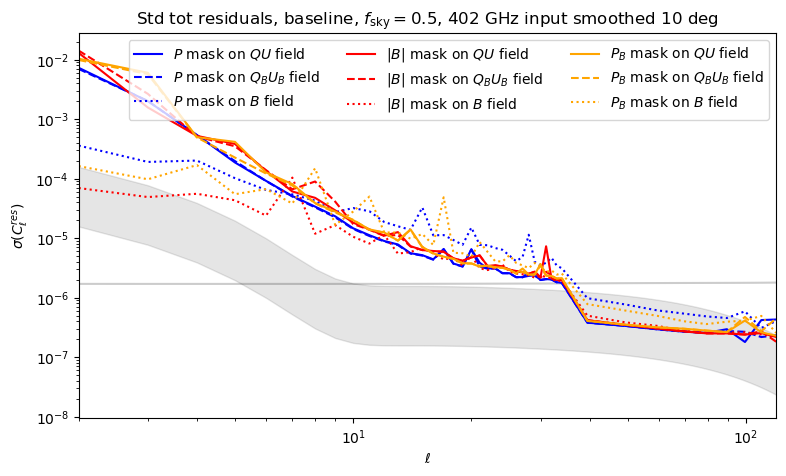

In [32]:
plt.figure(figsize=(9, 5))

plt.plot(ell, Cl_lens, color='black', alpha=0.2)
plt.fill_between(ell, 1e-3*Cl_tens, 1e-2*Cl_tens, color='black', alpha=0.1)

plt.plot(leff, np.std(statFGRs_P_on_QU, axis=0), label=r'$P$ mask on $QU$ field', color='blue')
plt.plot(leff, np.std(statFGRs_P_on_QBUB, axis=0), ls='dashed', label=r'$P$ mask on $Q_B U_B$ field', color='blue')
plt.plot(leff, np.std(statFGRs_P_on_B, axis=0), ls='dotted', label=r'$P$ mask on $B$ field', color='blue')

plt.plot(leff, np.std(statFGRs_B_on_QU, axis=0), label=r'$|B|$ mask on $QU$ field', color='red')
plt.plot(leff, np.std(statFGRs_B_on_QBUB, axis=0), ls='dashed', label=r'$|B|$ mask on $Q_B U_B$ field', color='red')
plt.plot(leff, np.std(statFGRs_B_on_B, axis=0), ls='dotted', label=r'$|B|$ mask on $B$ field', color='red')

plt.plot(leff, np.std(statFGRs_P_B_on_QU, axis=0), label=r'$P_B$ mask on $QU$ field', color='orange')
plt.plot(leff, np.std(statFGRs_P_B_on_QBUB, axis=0), ls='dashed', label=r'$P_B$ mask on $Q_B U_B$ field', color='orange')
plt.plot(leff, np.std(statFGRs_P_B_on_B, axis=0), ls='dotted', label=r'$P_B$ mask on $B$ field', color='orange')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\sigma(C_\ell^{res})$')
plt.xscale('log')
plt.yscale('log')
plt.xlim(min(leff), max(leff))
plt.legend(ncol=3)
plt.title(r'Std tot residuals, baseline, $f_{\rm sky}=0.5$, 402 GHz input smoothed 10 deg')

plt.show()

In [33]:
sysFGRs_P_on_QU_adaptative = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_402_10deg_baseline_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_B_on_QU_adaptative = np.load('../../BmodeLike/inputs/moments_baseline_0.5_B_402_10deg_baseline_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_P_B_on_QU_adaptative = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_B_402_10deg_baseline_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi

statFGRs_P_on_QU_adaptative = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_402_10deg_baseline_Nmt-fg_o1bts_adaptative/namaster_statFGRs.npy') / leff / (leff+1) * 2*np.pi
statFGRs_B_on_QU_adaptative = np.load('../../BmodeLike/inputs/moments_baseline_0.5_B_402_10deg_baseline_Nmt-fg_o1bts_adaptative/namaster_statFGRs.npy') / leff / (leff+1) * 2*np.pi
statFGRs_P_B_on_QU_adaptative = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_B_402_10deg_baseline_Nmt-fg_o1bts_adaptative/namaster_statFGRs.npy') / leff / (leff+1) * 2*np.pi

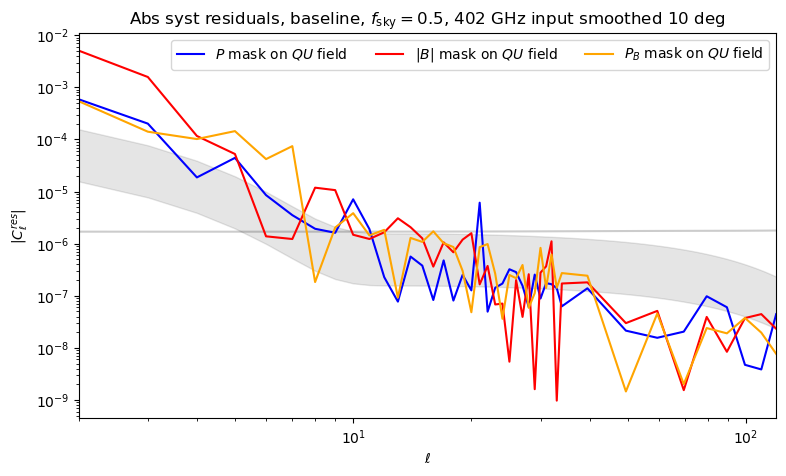

In [37]:
plt.figure(figsize=(9, 5))

plt.plot(ell, Cl_lens, color='black', alpha=0.2)
plt.fill_between(ell, 1e-3*Cl_tens, 1e-2*Cl_tens, color='black', alpha=0.1)

plt.plot(leff, np.abs(sysFGRs_P_on_QU_adaptative), label=r'$P$ mask on $QU$ field', color='blue')
plt.plot(leff, np.abs(sysFGRs_B_on_QU_adaptative), label=r'$|B|$ mask on $QU$ field', color='red')
plt.plot(leff, np.abs(sysFGRs_P_B_on_QU_adaptative), label=r'$P_B$ mask on $QU$ field', color='orange')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\vert C_\ell^{res} \vert$')
plt.xscale('log')
plt.yscale('log')
plt.xlim(min(leff), max(leff))
plt.legend(ncol=3)
plt.title(r'Abs syst residuals, baseline, $f_{\rm sky}=0.5$, 402 GHz input smoothed 10 deg')

plt.show()

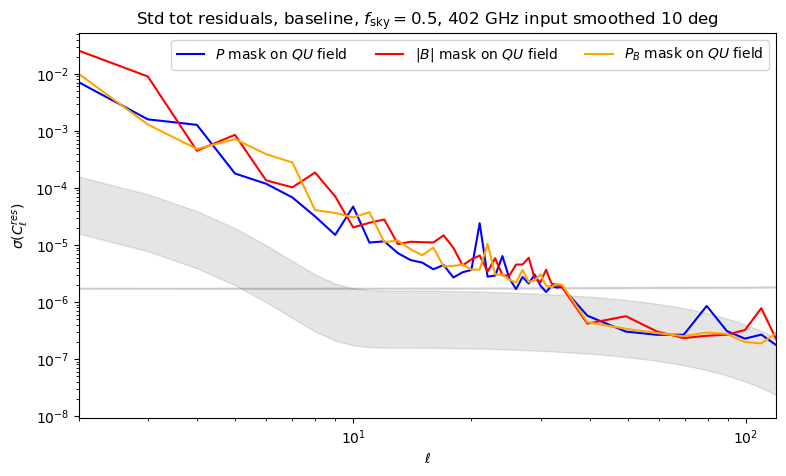

In [35]:
plt.figure(figsize=(9, 5))

plt.plot(ell, Cl_lens, color='black', alpha=0.2)
plt.fill_between(ell, 1e-3*Cl_tens, 1e-2*Cl_tens, color='black', alpha=0.1)

plt.plot(leff, np.std(statFGRs_P_on_QU_adaptative, axis=0), label=r'$P$ mask on $QU$ field', color='blue')
plt.plot(leff, np.std(statFGRs_B_on_QU_adaptative, axis=0), label=r'$|B|$ mask on $QU$ field', color='red')
plt.plot(leff, np.std(statFGRs_P_B_on_QU_adaptative, axis=0), label=r'$P_B$ mask on $QU$ field', color='orange')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\sigma(C_\ell^{res})$')
plt.xscale('log')
plt.yscale('log')
plt.xlim(min(leff), max(leff))
plt.legend(ncol=3)
plt.title(r'Std tot residuals, baseline, $f_{\rm sky}=0.5$, 402 GHz input smoothed 10 deg')

plt.show()

In [61]:
sysFGRs_402_baseline = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_402_10deg_baseline_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_fgbuster_dust_baseline = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_fgbuster_dust_10deg_baseline_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_fgbuster_dustsync_baseline = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_fgbuster_dustsync_10deg_baseline_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_gnilc_402_baseline = np.load('../../BmodeLike/inputs/moments_baseline_0.5_P_gnilc_402_10deg_baseline_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi

sysFGRs_402_medium = np.load('../../BmodeLike/inputs/moments_medium_complexity_0.5_P_402_10deg_medium_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_fgbuster_dust_medium = np.load('../../BmodeLike/inputs/moments_medium_complexity_0.5_P_fgbuster_dust_10deg_medium_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_fgbuster_dustsync_medium = np.load('../../BmodeLike/inputs/moments_medium_complexity_0.5_P_fgbuster_dustsync_10deg_medium_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_gnilc_402_medium = np.load('../../BmodeLike/inputs/moments_medium_complexity_0.5_P_gnilc_402_10deg_medium_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi

sysFGRs_402_high = np.load('../../BmodeLike/inputs/moments_high_complexity_0.5_P_402_10deg_high_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_fgbuster_dust_high = np.load('../../BmodeLike/inputs/moments_high_complexity_0.5_P_fgbuster_dust_10deg_high_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_fgbuster_dustsync_high = np.load('../../BmodeLike/inputs/moments_high_complexity_0.5_P_fgbuster_dustsync_10deg_high_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi
sysFGRs_gnilc_402_high = np.load('../../BmodeLike/inputs/moments_high_complexity_0.5_P_gnilc_402_10deg_high_Nmt-fg_o1bts_adaptative/namaster_sysFGRs.npy') / leff / (leff+1) * 2*np.pi

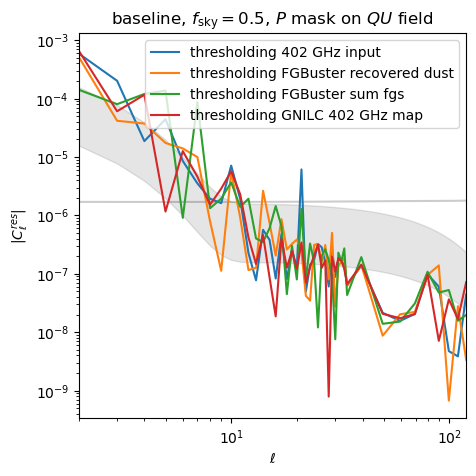

In [62]:
plt.figure(figsize=(5, 5))

plt.plot(ell, Cl_lens, color='black', alpha=0.2)
plt.fill_between(ell, 1e-3*Cl_tens, 1e-2*Cl_tens, color='black', alpha=0.1)

plt.plot(leff, np.abs(sysFGRs_402_baseline), label='thresholding 402 GHz input')
plt.plot(leff, np.abs(sysFGRs_fgbuster_dust_baseline), label='thresholding FGBuster recovered dust')
plt.plot(leff, np.abs(sysFGRs_fgbuster_dustsync_baseline), label='thresholding FGBuster sum fgs')
plt.plot(leff, np.abs(sysFGRs_gnilc_402_baseline), label='thresholding GNILC 402 GHz map')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\vert C_\ell^{res} \vert$')
plt.xscale('log')
plt.yscale('log')
plt.xlim(min(leff), max(leff))
plt.legend()
plt.title(r'baseline, $f_{\rm sky}=0.5$, $P$ mask on $QU$ field')

plt.show()

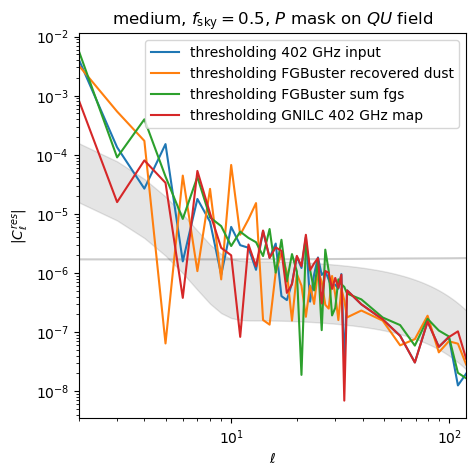

In [63]:
plt.figure(figsize=(5, 5))

plt.plot(ell, Cl_lens, color='black', alpha=0.2)
plt.fill_between(ell, 1e-3*Cl_tens, 1e-2*Cl_tens, color='black', alpha=0.1)

plt.plot(leff, np.abs(sysFGRs_402_medium), label='thresholding 402 GHz input')
plt.plot(leff, np.abs(sysFGRs_fgbuster_dust_medium), label='thresholding FGBuster recovered dust')
plt.plot(leff, np.abs(sysFGRs_fgbuster_dustsync_medium), label='thresholding FGBuster sum fgs')
plt.plot(leff, np.abs(sysFGRs_gnilc_402_medium), label='thresholding GNILC 402 GHz map')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\vert C_\ell^{res} \vert$')
plt.xscale('log')
plt.yscale('log')
plt.xlim(min(leff), max(leff))
plt.legend()
plt.title(r'medium, $f_{\rm sky}=0.5$, $P$ mask on $QU$ field')

plt.show()

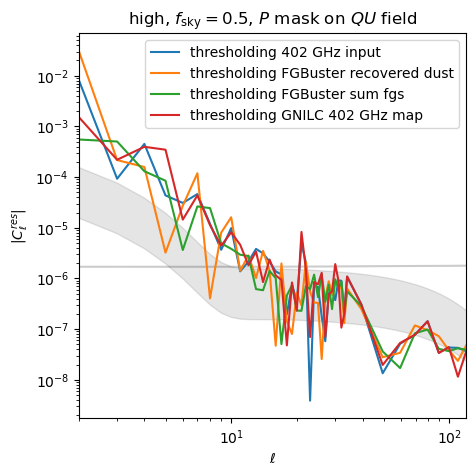

In [64]:
plt.figure(figsize=(5, 5))

plt.plot(ell, Cl_lens, color='black', alpha=0.2)
plt.fill_between(ell, 1e-3*Cl_tens, 1e-2*Cl_tens, color='black', alpha=0.1)

plt.plot(leff, np.abs(sysFGRs_402_high), label='thresholding 402 GHz input')
plt.plot(leff, np.abs(sysFGRs_fgbuster_dust_high), label='thresholding FGBuster recovered dust')
plt.plot(leff, np.abs(sysFGRs_fgbuster_dustsync_high), label='thresholding FGBuster sum fgs')
plt.plot(leff, np.abs(sysFGRs_gnilc_402_high), label='thresholding GNILC 402 GHz map')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\vert C_\ell^{res} \vert$')
plt.xscale('log')
plt.yscale('log')
plt.xlim(min(leff), max(leff))
plt.legend()
plt.title(r'high, $f_{\rm sky}=0.5$, $P$ mask on $QU$ field')

plt.show()